In [69]:
#import libraries
#load data
#eda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [70]:
df = pd.read_csv("diabetes.csv")

In [71]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,16,176,71,11,0,44.9,0.212,68,0
1,0,132,73,18,151,30.5,0.154,79,0
2,6,151,71,22,179,28.5,0.306,27,1
3,9,191,56,5,0,32.1,0.139,25,1
4,15,179,42,0,0,25.6,0.195,30,1


In [72]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [74]:
df['Outcome'].skew()

np.float64(-0.28462906926172027)

<Axes: xlabel='Outcome', ylabel='Count'>

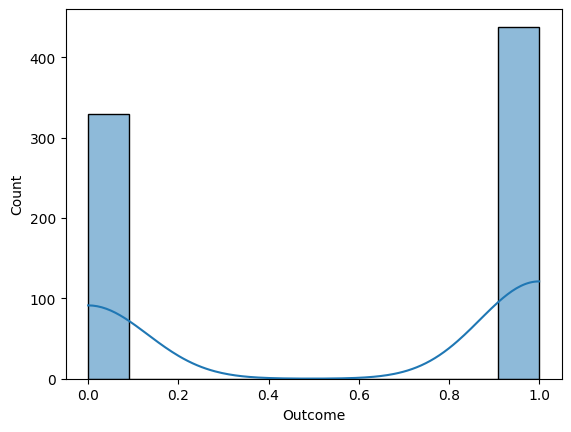

In [75]:
sns.histplot(df['Outcome'],kde=True)

<Axes: ylabel='Outcome'>

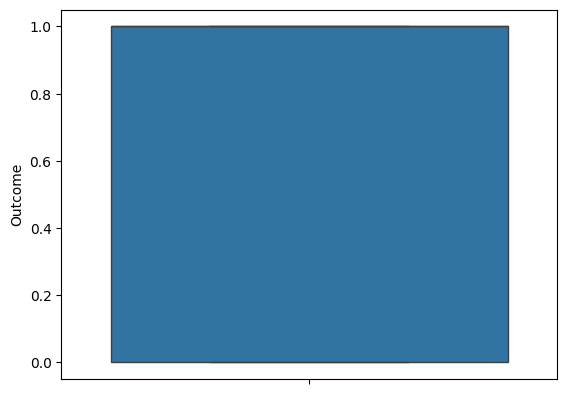

In [76]:
sns.boxplot(df['Outcome'])

In [77]:
#count plot for checking class imbalance
#diff bet categorical values

#cat val = 2 binary classification
#more = multiclass classification

<Axes: xlabel='Outcome'>

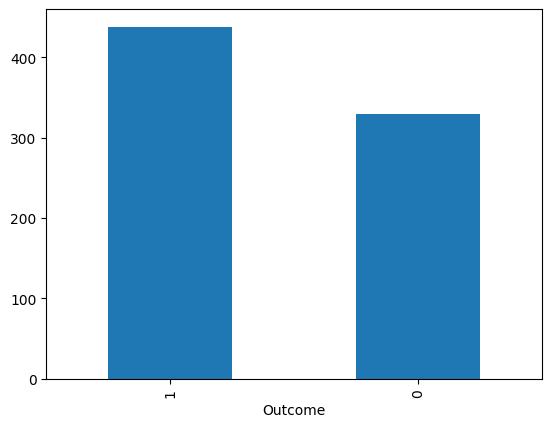

In [78]:
df['Outcome'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

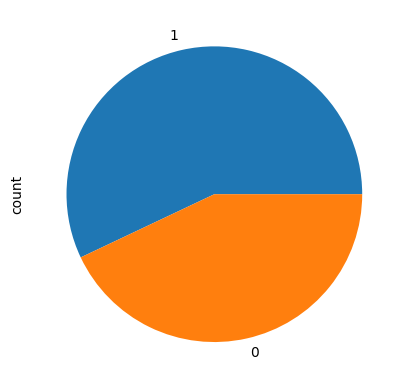

In [79]:
df['Outcome'].value_counts().plot(kind='pie')

<Axes: >

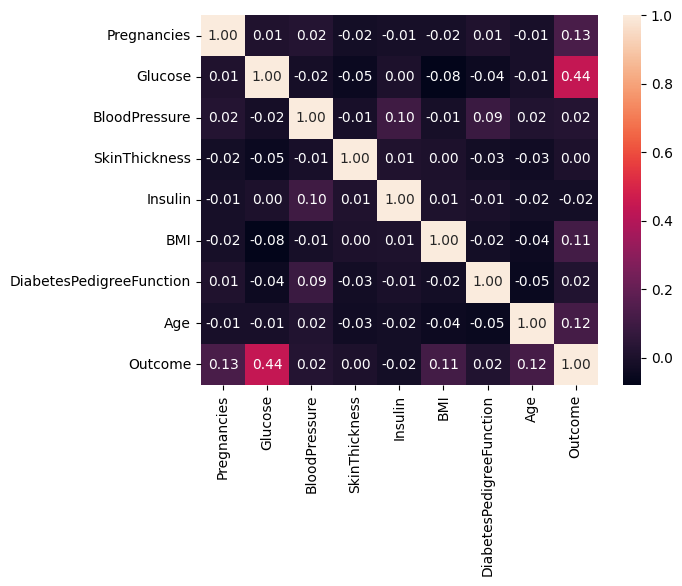

In [80]:
sns.heatmap(df.corr(),annot=True,fmt='.2f')

In [81]:
#split columns for training and testing
X=df.drop('Outcome',axis=1)
y=df['Outcome']

print(X.shape)
print(y.shape)


(768, 8)
(768,)


In [82]:
#do we need to use StandardScaler .......we use standardscaler when we are working with distance based algorithm but when we are working on probability or tree based algo we donnt use standardscaler

In [83]:
#train test splt
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [84]:
#BOOSTING algorithm train
#adaboost
#XGboost
#gradientboost

In [85]:
#creating adaboost model
from sklearn.ensemble import AdaBoostClassifier
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import accuracy_score

In [86]:
AdaBoost_model=AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
  random_state=42
    )

In [87]:
AdaBoost_model.fit(X_train,y_train)

AdaBoostClassifier(random_state=42)

In [88]:
#prediction on unseen data
AdaBoost_Pred=AdaBoost_model.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,AdaBoost_Pred)

0.6948051948051948

In [90]:
#acuracy for train
accuracy_score(y_train,AdaBoost_model.predict(X_train))

0.754071661237785

In [91]:
#make a model of xg boost
from xgboost import XGBClassifier

In [92]:
XGBoost_model=XGBClassifier(
    n_estimators=50,
    learning_rate=1.0,
  random_state=42,
   max_dept=4
    )

In [93]:
#train xgboost model
XGBoost_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:38:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_dept" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1.0, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_dept=4,
              max_depth=None, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=50, n_jobs=None, ...)

In [94]:
XGBoost_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:38:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_dept" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1.0, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_dept=4,
              max_depth=None, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=50, n_jobs=None, ...)

In [95]:
XGBoost_Pred=XGBoost_model.predict(X_test)


In [96]:
accuracy_score(y_test,XGBoost_Pred)

0.6428571428571429

In [97]:
accuracy_score(y_train,XGBoost_model.predict(X_train))

1.0

In [98]:
#train predict evaluate gradient boost model

In [99]:
from sklearn.ensemble import GradientBoostingClassifier

In [100]:
GradientBoost_model=GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=1.0,
  random_state=42,
   max_depth=4
    )

In [101]:
#train gradient boost model
GradientBoost_model.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=1.0, max_depth=4, n_estimators=50,
                           random_state=42)

In [102]:
#prediction on unseen data
GradientBoost_Pred=GradientBoost_model.predict(X_test)

In [103]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,GradientBoost_Pred)

0.6168831168831169

In [104]:
#accuracy for train
accuracy_score(y_train,GradientBoost_model.predict(X_train))

1.0

In [105]:
GradientBoost_model.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=1.0, max_depth=4, n_estimators=50,
                           random_state=42)

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [107]:
#train the gradient boost model
model = GradientBoostingClassifier()

model.fit(X_train, y_train)

GradientBoostingClassifier()

In [108]:
#make prediction
y_pred = model.predict(X_test)

In [109]:
model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=3
)

model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=50)

In [110]:
#training accuracy
train_accuracy = model.score(X_train, y_train)



In [111]:
#testing accuracy
test_accuracy = model.score(X_test, y_test)

In [112]:
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.8127035830618893


In [113]:
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.6233766233766234


In [114]:
# may 25 excel and power bi next saturday ml challenge

In [115]:
#in any ml model first we create base line model

In [116]:
#testing on naive bayes

In [117]:
from sklearn.naive_bayes import GaussianNB

In [118]:
naive_model = GaussianNB()

In [119]:
naive_model.fit(X_train,y_train)

GaussianNB()

In [120]:
accuracy_score(y_test,naive_model.predict(X_test))

0.7077922077922078

In [121]:
accuracy_score(y_train,naive_model.predict(X_train))


0.7296416938110749

In [122]:
#testing on logistic

In [123]:
from sklearn.linear_model import LogisticRegression

In [124]:
logistic_model = LogisticRegression()

In [125]:
logistic_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [126]:
accuracy_score(y_test,logistic_model.predict(X_test))

0.6558441558441559

In [127]:
accuracy_score(y_train,logistic_model.predict(X_train))

0.7231270358306189

In [128]:
#testing on knn

In [129]:
from sklearn.neighbors import KNeighborsClassifier

In [130]:
knn_model = KNeighborsClassifier()

In [131]:
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [132]:
accuracy_score(y_test,knn_model.predict(X_test))

0.6623376623376623

In [133]:
accuracy_score(y_train,knn_model.predict(X_train))

0.758957654723127

In [134]:
import joblib

In [135]:
joblib.dump(naive_model,'naive_bayes_model.pkl')

['naive_bayes_model.pkl']

In [136]:

model = joblib.load("naive_bayes_model.pkl")